

本实验使用纯 NumPy 构建一个两层 ReLU 神经网络，对一维目标函数进行拟合，并在测试集上验证效果。

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)



这里选择一个带有周期项和非线性项的函数：

$$f(x) = \sin(x) +x^2 - 0.5x$$

在区间 $[-3, 3]$ 上均匀采样训练集和测试集。

In [3]:
def target_function(x):
    return np.sin(x)+x**2 - 0.5 * x


n_train = 256
n_test = 128

x_train = np.linspace(-3, 3, n_train).reshape(-1, 1)
y_train = target_function(x_train)

x_test = np.linspace(-3, 3, n_test).reshape(-1, 1)
y_test = target_function(x_test)

print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)

x_train: (256, 1)
y_train: (256, 1)
x_test: (128, 1)
y_test: (128, 1)


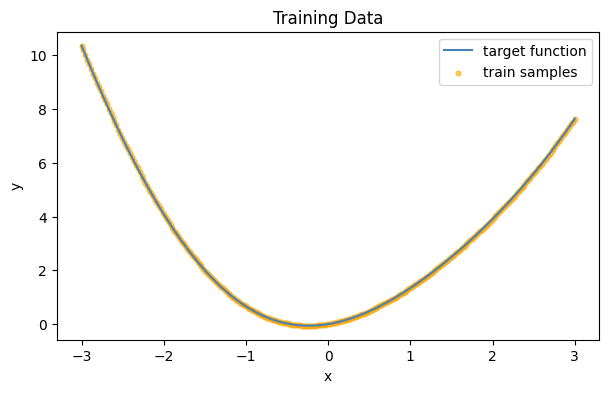

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(x_train, y_train, label='target function', color='steelblue')
plt.scatter(x_train, y_train, s=12, color='orange', alpha=0.6, label='train samples')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Data')
plt.legend()
plt.show()

## 定义两层 ReLU 网络

网络结构为：

`1 -> hidden_dim -> 1`

其中隐藏层使用 ReLU 激活函数，输出层为线性输出。

In [5]:
def relu(x):
    return np.maximum(0, x)


def relu_grad(x):
    return (x > 0).astype(np.float64)


def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)


input_dim = 1
hidden_dim = 64
output_dim = 1

W1 = 0.1 * np.random.randn(input_dim, hidden_dim)
b1 = np.zeros((1, hidden_dim))
W2 = 0.1 * np.random.randn(hidden_dim, output_dim)
b2 = np.zeros((1, output_dim))

## 前向传播与反向传播

In [6]:
def forward_pass(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    y_pred = a1 @ W2 + b2
    cache = {
        'X': X,
        'z1': z1,
        'a1': a1,
        'y_pred': y_pred
    }
    return y_pred, cache


def backward_pass(cache, y_true, W2):
    X = cache['X']
    z1 = cache['z1']
    a1 = cache['a1']
    y_pred = cache['y_pred']
    batch_size = X.shape[0]

    dy_pred = 2 * (y_pred - y_true) / batch_size
    dW2 = a1.T @ dy_pred
    db2 = np.sum(dy_pred, axis=0, keepdims=True)

    da1 = dy_pred @ W2.T
    dz1 = da1 * relu_grad(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [7]:
learning_rate = 0.01
epochs = 5000

train_loss_history = []
test_loss_history = []

for epoch in range(epochs):
    y_pred_train, cache = forward_pass(x_train, W1, b1, W2, b2)
    train_loss = mse_loss(y_pred_train, y_train)

    dW1, db1, dW2, db2 = backward_pass(cache, y_train, W2)

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    y_pred_test, _ = forward_pass(x_test, W1, b1, W2, b2)
    test_loss = mse_loss(y_pred_test, y_test)

    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)

    if epoch % 500 == 0:
        print(f'epoch={epoch:4d} train_loss={train_loss:.6f} test_loss={test_loss:.6f}')

print(f'final train_loss={train_loss_history[-1]:.6f}')
print(f'final test_loss={test_loss_history[-1]:.6f}')

epoch=   0 train_loss=16.661308 test_loss=15.953840
epoch= 500 train_loss=0.192322 test_loss=0.196676
epoch=1000 train_loss=0.085465 test_loss=0.087976
epoch=1500 train_loss=0.050615 test_loss=0.052235
epoch=2000 train_loss=0.038382 test_loss=0.039531
epoch=2500 train_loss=0.028265 test_loss=0.029172
epoch=3000 train_loss=0.019236 test_loss=0.019952
epoch=3500 train_loss=0.012788 test_loss=0.013362
epoch=4000 train_loss=0.008773 test_loss=0.009227
epoch=4500 train_loss=0.006416 test_loss=0.006784
final train_loss=0.004938
final test_loss=0.005243


## 拟合效果可视化

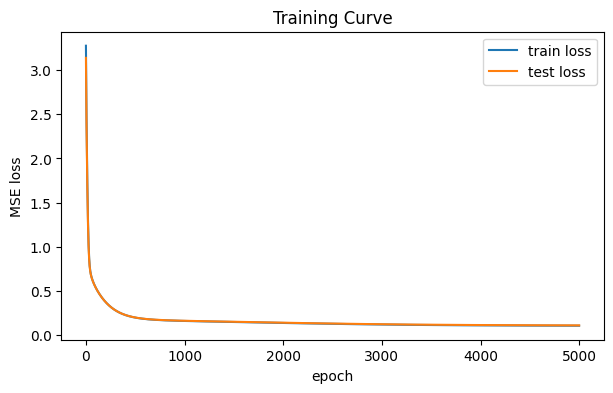

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(train_loss_history, label='train loss')
plt.plot(test_loss_history, label='test loss')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('Training Curve')
plt.legend()
plt.show()

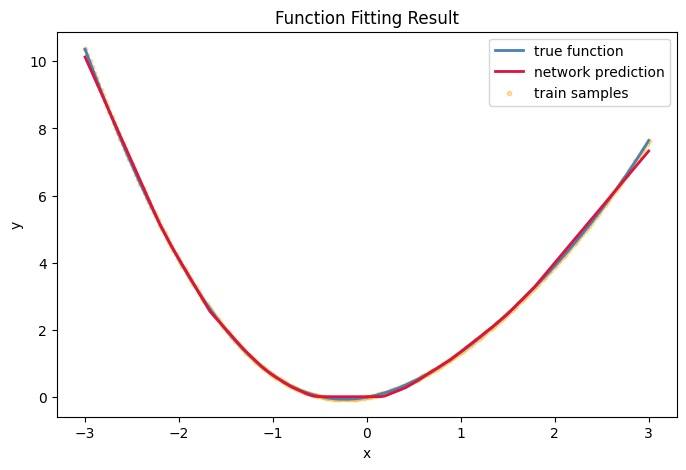

In [8]:
x_plot = np.linspace(-3, 3, 400).reshape(-1, 1)
y_plot = target_function(x_plot)
y_fit, _ = forward_pass(x_plot, W1, b1, W2, b2)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, label='true function', color='steelblue', linewidth=2)
plt.plot(x_plot, y_fit, label='network prediction', color='crimson', linewidth=2)
plt.scatter(x_train, y_train, s=10, alpha=0.35, color='orange', label='train samples')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Function Fitting Result')
plt.legend()
plt.show()

## 测试集误差

最后输出测试集上的均方误差，用于评估拟合效果。

In [9]:
y_test_pred, _ = forward_pass(x_test, W1, b1, W2, b2)
test_mse = mse_loss(y_test_pred, y_test)
print('Test MSE:', test_mse)

Test MSE: 0.005243193233156224
